# Chapter 4. 매개변수화 양자 회로 (PQC)

**Quantum AI: 핸즈온 양자머신러닝 with PennyLane — Part 1**

## 학습 목표
- 매개변수화 회로(PQC)의 표준 구조 익히기 (인코딩 → ansatz → 측정)
- PennyLane의 ansatz 템플릿 비교: `BasicEntanglerLayers`, `StronglyEntanglingLayers`
- 회로 깊이가 표현력에 미치는 영향 확인
- 회로 파라미터 수와 표현력의 관계

In [20]:
%pip install -q koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [21]:
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

## 4.1 PQC의 표준 구조
일반적인 PQC는 다음 세 단계로 구성된다.

```
  [입력 인코딩 U_in(x)]  →  [변분 ansatz U_var(θ)]  →  [측정 ⟨O⟩]
```

직접 구현해본다.

PQC 출력: 0.6622
0: ──RY(0.10)───RZ(0.20)─╭●──RY(0.80)───────────┤  <Z>
1: ──RY(0.50)───RZ(0.40)─╰X─╭●─────────RY(1.00)─┤     
2: ──RY(-0.30)──RZ(0.60)────╰X─────────RY(1.20)─┤     


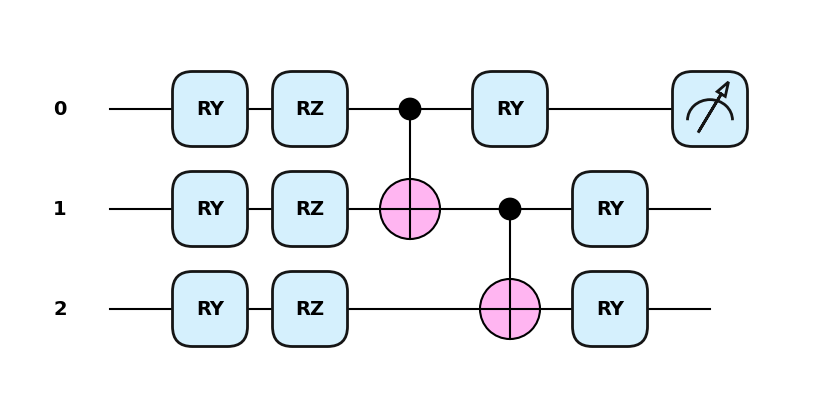

In [12]:
n_qubits = 3
dev = qml.device('default.qubit', wires=n_qubits)

@qml.qnode(dev)
def pqc(x, theta):
    # (1) 입력 인코딩: 각 특징을 RY 회전으로 주입
    for i in range(n_qubits):
        qml.RY(x[i], wires=i)
    # (2) 변분 ansatz: 회전 + 얽힘
    for i in range(n_qubits):
        qml.RZ(theta[i], wires=i)
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])
    for i in range(n_qubits):
        qml.RY(theta[n_qubits + i], wires=i)
    # (3) 측정
    return qml.expval(qml.PauliZ(0))

x = np.array([0.1, 0.5, -0.3])
theta = np.array([0.2, 0.4, 0.6, 0.8, 1.0, 1.2])
print(f'PQC 출력: {pqc(x, theta):.4f}')
print(qml.draw(pqc)(x, theta))

fig, ax = qml.draw_mpl(pqc, style="pennylane")(x, theta)
plt.show()

## 4.2 PennyLane 템플릿 사용하기
위 코드를 직접 쓰는 대신 PennyLane이 제공하는 템플릿을 사용할 수 있다.

PQC 출력: -0.4978


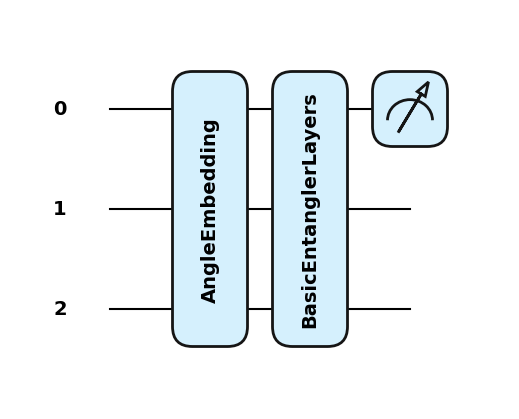

In [13]:
@qml.qnode(dev)
def pqc_template(x, weights):
    # 한 줄로 인코딩
    qml.AngleEmbedding(x, wires=range(n_qubits), rotation='Y')
    # 한 줄로 변분 ansatz
    qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
    return qml.expval(qml.PauliZ(0))

# BasicEntanglerLayers의 weights shape: (n_layers, n_qubits)
weights = np.random.RandomState(0).uniform(0, 2 * np.pi, (2, n_qubits))
print(f'PQC 출력: {pqc_template(x, weights):.4f}')

fig, ax = qml.draw_mpl(pqc_template, style="pennylane")(x, weights)
plt.show()

## 4.3 BasicEntanglerLayers vs StronglyEntanglingLayers
두 ansatz의 구조를 비교해본다.

In [14]:
dev4 = qml.device('default.qubit', wires=4)

@qml.qnode(dev4)
def basic(weights):
    qml.BasicEntanglerLayers(weights, wires=range(4))
    return qml.expval(qml.PauliZ(0))

@qml.qnode(dev4)
def strong(weights):
    qml.StronglyEntanglingLayers(weights, wires=range(4))
    return qml.expval(qml.PauliZ(0))

# 파라미터 모양이 다르다
basic_shape = qml.BasicEntanglerLayers.shape(n_layers=2, n_wires=4)
strong_shape = qml.StronglyEntanglingLayers.shape(n_layers=2, n_wires=4)
print('BasicEntanglerLayers weights shape:', basic_shape)
print('StronglyEntanglingLayers weights shape:', strong_shape)

# 파라미터 수 비교
print(f'BasicEntanglerLayers 파라미터 수:    {np.prod(basic_shape)}')
print(f'StronglyEntanglingLayers 파라미터 수: {np.prod(strong_shape)}')

BasicEntanglerLayers weights shape: (2, 4)
StronglyEntanglingLayers weights shape: (2, 4, 3)
BasicEntanglerLayers 파라미터 수:    8
StronglyEntanglingLayers 파라미터 수: 24


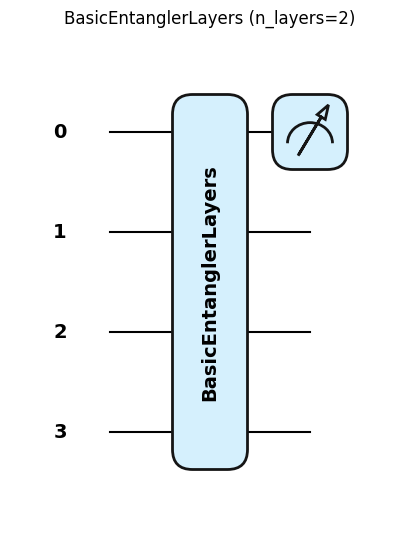

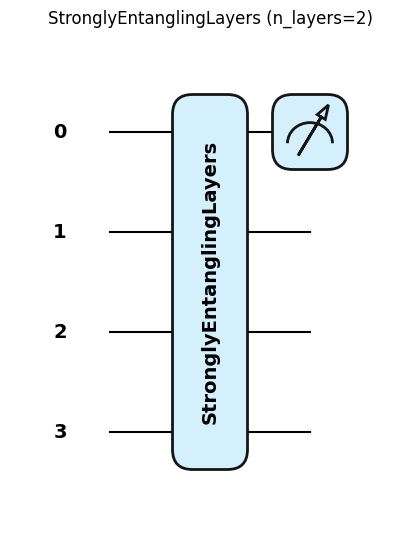

In [16]:
# 두 회로 시각화
w_basic = np.random.RandomState(1).uniform(0, 2 * np.pi, basic_shape)
w_strong = np.random.RandomState(1).uniform(0, 2 * np.pi, strong_shape)

fig, ax = qml.draw_mpl(basic, style="pennylane")(w_basic)
ax.set_title('BasicEntanglerLayers (n_layers=2)')
plt.show()

fig, ax = qml.draw_mpl(strong, style="pennylane")(w_strong)
ax.set_title('StronglyEntanglingLayers (n_layers=2)')
plt.show()

## 4.4 깊이가 표현력에 미치는 영향
고정된 입력에 대해 무작위 파라미터를 여러 번 샘플링하여 출력 분포를 본다. 표현력이 높을수록 출력이 더 넓은 범위에 분포한다.

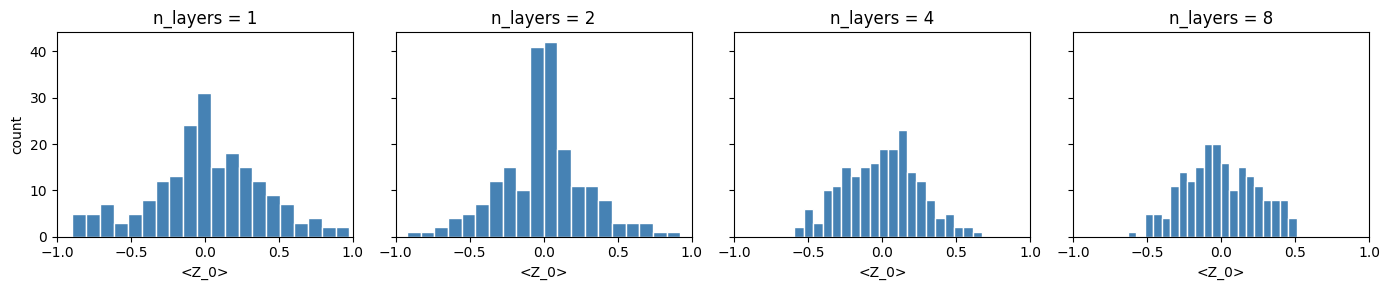

In [17]:
rng = np.random.RandomState(42)
n_samples = 200
layer_counts = [1, 2, 4, 8]

fig, axes = plt.subplots(1, len(layer_counts), figsize=(14, 3), sharey=True)

for ax, n_layers in zip(axes, layer_counts):
    dev_x = qml.device('default.qubit', wires=4)
    @qml.qnode(dev_x)
    def circ(w):
        qml.StronglyEntanglingLayers(w, wires=range(4))
        return qml.expval(qml.PauliZ(0))
    shape = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=4)
    outputs = np.array(
        [circ(rng.uniform(0, 2 * np.pi, shape)) for _ in range(n_samples)]
    )
    ax.hist(outputs, bins=20, color='steelblue', edgecolor='white')
    ax.set_title(f'n_layers = {n_layers}')
    ax.set_xlim(-1, 1)
    ax.set_xlabel('<Z_0>')
axes[0].set_ylabel('count')
plt.tight_layout()
plt.show()

**관찰.** 깊이가 1일 때는 출력이 좁은 구간에 몰려 있지만, 깊이가 깊어질수록 출력이 [-1, 1] 전 구간에 균등하게 분포한다. 표현력이 높아진 것이다.

## 4.5 학습 가능한 PQC 만들어보기
PQC를 ML 모델처럼 사용하는 첫 발걸음 — 간단한 cost function을 최소화한다.
(자동미분과 옵티마이저는 다음 장에서 자세히 다룬다)

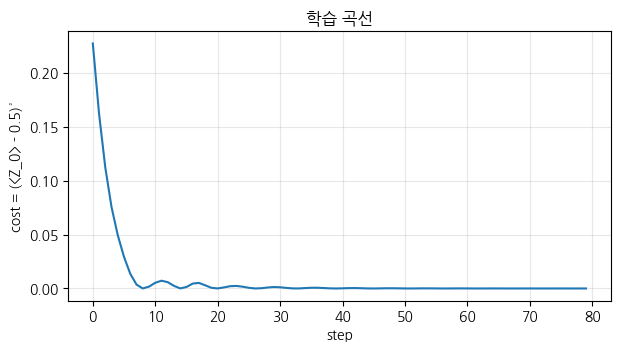

최종 cost = 0.000006, 최종 <Z_0> = 0.5029


In [22]:
# 목표: <Z_0> = 0.5가 되도록 파라미터 학습
@qml.qnode(dev4, interface='autograd')
def circuit(weights):
    qml.StronglyEntanglingLayers(weights, wires=range(4))
    return qml.expval(qml.PauliZ(0))

def cost(weights):
    return (circuit(weights) - 0.5) ** 2

shape = qml.StronglyEntanglingLayers.shape(n_layers=3, n_wires=4)
weights = pnp.array(
    np.random.RandomState(7).uniform(0, 2 * np.pi, shape),
    requires_grad=True,
)

opt = qml.AdamOptimizer(stepsize=0.05)
history = []
for step in range(80):
    weights, c = opt.step_and_cost(cost, weights)
    history.append(c)

plt.figure(figsize=(7, 3.5))
plt.plot(history)
plt.xlabel('step')
plt.ylabel('cost = (<Z_0> - 0.5)²')
plt.title('학습 곡선')
plt.grid(alpha=0.3)
plt.show()
print(f'최종 cost = {history[-1]:.6f}, 최종 <Z_0> = {circuit(weights):.4f}')

## 4.6 정리
- PQC = 인코딩 + 변분 ansatz + 측정의 3단 구조
- `qml.templates`는 자주 쓰는 ansatz를 패키징해두었다.
- 회로 깊이를 늘리면 표현력이 향상되지만 학습 난이도도 함께 올라간다.
- 다음 장에서 자동미분과 다양한 옵티마이저를 깊이 다룬다.